## accuracy vs optimizer
- This function is used to understand which optimizer suits a certain model better based on accuracy. 
- Optimizers affect the learning speed and stability of the model. 
- This function creates a separate model for each optimizer, trains it on the same data, and then compares the accuracy results.

In [11]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt

# Recreate the same simple dataset
np.random.seed(0)
tf.random.set_seed(0)

def make_sample(label, noise=0.05):
    img = np.zeros((8, 8), dtype=np.float32)
    if label == 0:
        img[:, 3] = 1.0
    elif label == 1:
        img[3, :] = 1.0
    else:
        np.fill_diagonal(img, 1.0)
    if noise:
        img += np.random.normal(0.0, noise, img.shape).astype(np.float32)
    return np.clip(img, 0.0, 1.0)

n_per_class = 200
X, y = [], []
for c in range(3):
    for _ in range(n_per_class):
        X.append(make_sample(c))
        y.append(c)

X = np.array(X)[..., np.newaxis]   # (600, 8, 8, 1)
y = np.array(y, dtype=np.int32)    # (600,)

# Same split as before
idx = np.random.permutation(len(X))
X, y = X[idx], y[idx]
split = int(0.8 * len(X))
x_train, y_train = X[:split], y[:split]
x_test,  y_test  = X[split:], y[split:]

# Load the saved .keras file
loaded_model = keras.models.load_model("my_model.keras")
loaded_model.summary()

# Evaluate the loaded model
loss, acc = loaded_model.evaluate(x_test, y_test, verbose=0)
print(f"Loaded model - test accuracy: {acc:.3f}")

# Predict a few samples
probs = loaded_model.predict(x_test[:5], verbose=0)  # shape: (5, 3)
preds = probs.argmax(axis=1)
print("Predictions:", preds)
print("True labels:", y_test[:5].tolist())

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_rotation_1               │ (None, 28, 28, 1)      │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_translation_1            │ (None, 28, 28, 1)      │             0 │
│ (RandomTranslation)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gaussian_noise_3                │ (None, 28, 28, 1)      │             0 │
│ (GaussianNoise)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 28, 28, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 14, 14, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 14, 14, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 14, 14, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 7, 7, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 7, 7, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 7, 7, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 72,608 (283.63 KB)

 Trainable params: 24,138 (94.29 KB)

 Non-trainable params: 192 (768.00 B)

 Optimizer params: 48,278 (188.59 KB)

Loaded model - test accuracy: 0.000
Predictions: [1 2 5 1 1]
True labels: [2, 1, 0, 2, 2]


SGD_lr0.1 -> 1.000
SGD_lr0.01 -> 1.000
SGD_lr0.001 -> 0.642
Adam_lr0.1 -> 1.000
Adam_lr0.01 -> 1.000
Adam_lr0.001 -> 0.642
RMSprop_lr0.1 -> 1.000
RMSprop_lr0.01 -> 1.000
RMSprop_lr0.001 -> 1.000

Best optimizer: SGD_lr0.1
Accuracy: 1.0


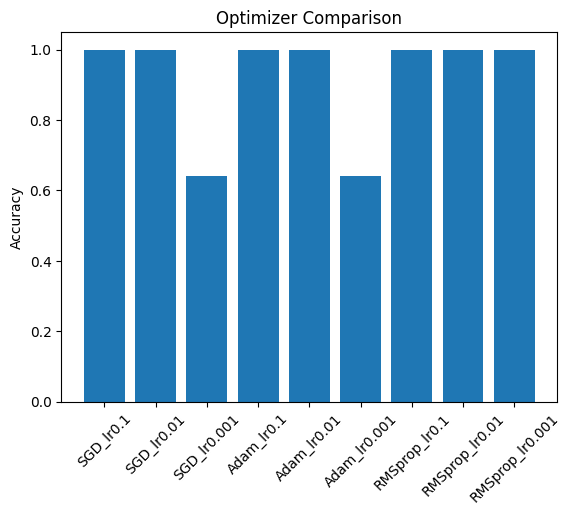

In [12]:
optimizers = [
    tf.keras.optimizers.SGD,
    tf.keras.optimizers.Adam,
    tf.keras.optimizers.RMSprop
]

learning_rates = [0.1, 0.01, 0.001]

def optimizer_vs_accuracy(optimizers, learning_rates, x_train, y_train, x_test, y_test, epochs=5):

    results = {}

    for opt_class in optimizers:
        for lr in learning_rates:

            optimizer = opt_class(learning_rate=lr)

            model = tf.keras.Sequential([
                tf.keras.layers.Flatten(input_shape=(8,8,1)),
                tf.keras.layers.Dense(8, activation="relu"),
                tf.keras.layers.Dense(3, activation="softmax")
            ])

            model.compile(
                optimizer=optimizer,
                loss="sparse_categorical_crossentropy",
                metrics=["accuracy"]
            )

            model.fit(x_train, y_train, epochs=epochs, verbose=0)

            loss, acc = model.evaluate(x_test, y_test, verbose=0)

            key = f"{opt_class.__name__}_lr{lr}"
            results[key] = acc

            print(f"{key} -> {acc:.3f}")

    best = max(results, key=results.get)

    print("\nBest optimizer:", best)
    print("Accuracy:", results[best])
    
    plt.bar(results.keys(), results.values())
    plt.xticks(rotation=45)
    plt.ylabel("Accuracy")
    plt.title("Optimizer Comparison")
    plt.show()

    return results

results = optimizer_vs_accuracy(
    optimizers,
    learning_rates,
    x_train,
    y_train,
    x_test,
    y_test,
    epochs=6
)